In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder 

import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = os.path.abspath("..")

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

DATA_PATH = os.path.join(DATA_DIR, "executions.csv")

In [3]:
df_raw= pd.read_csv(DATA_PATH)
print("Data loaded successfully!")

print(f"Raw shape: {df_raw.shape}")
print(f"Columns:   {df_raw.columns.tolist()}\n")

Data loaded successfully!
Raw shape: (1410, 23)
Columns:   ['execution_id', 'program_id', 'variant', 'family', 'strategy', 'expected_patterns', 'pattern', 'severity', 'impact_score', 'line_number', 'loop_depth', 'is_inside_loop', 'co_occurring_patterns', 'source_lines', 'complexity_class', 'error_count', 'execution_time_ms', 'total_suggestions', 'score', 'grade', 'pathological', 'source_path', 'status']



## Initial Data Exploration

<b>Cleaning - Drop Rows<b>

In [4]:
df = df_raw[df_raw["strategy"] != "none"].copy()
print(f"Dropped {len(df_raw) - len(df)} rows with strategy='none'  ->  {len(df)} rows remain")

Dropped 6 rows with strategy='none'  ->  1404 rows remain


<b>Cleaning - Drop Columns<b>

In [5]:
COLUMNS_TO_DROP = [
    'execution_id',
    'program_id',
    'source_path',
    'status',
    'grade',
    'error_count',
    'pathological',
    'execution_time_ms',
    'loop_depth',
    'is_inside_loop',
    'expected_patterns',
    'family'
]
 
df = df.drop(columns=COLUMNS_TO_DROP)
print(f"Shape after drops: {df.shape}")
print(f"Columns kept:  {df.columns.tolist()}")

Shape after drops: (1404, 11)
Columns kept:  ['variant', 'strategy', 'pattern', 'severity', 'impact_score', 'line_number', 'co_occurring_patterns', 'source_lines', 'complexity_class', 'total_suggestions', 'score']


<b>Preprocessing<b>

In [6]:
def safe_numeric(series):
    return pd.to_numeric(series, errors='coerce')

# apply safe conversions
for col in ['impact_score','line_number','source_lines','total_suggestions','score']:
    if col in df.columns:
        df[col] = safe_numeric(df[col])

# handle nulls
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

# safe casting
df['impact_score'] = df['impact_score'].astype(float)
df['line_number'] = df['line_number'].astype(int)
df['source_lines'] = df['source_lines'].astype(int)
df['total_suggestions'] = df['total_suggestions'].astype(int)
df['score'] = df['score'].astype(float)

# validation
remaining_nulls = df.isnull().sum().sum()
print('Remaining nulls:', remaining_nulls)
print('Preprocessing complete')


Remaining nulls: 0
Preprocessing complete


<b>Null Check<b>

In [7]:
nulls = df.isnull().sum()
assert nulls.sum() == 0, f"Unexpected nulls found:\n{nulls[nulls > 0]}"
print("None -> dataset is complete")

None -> dataset is complete


<b>Type Allignment<b>

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1404 entries, 0 to 1403
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   variant                1404 non-null   str    
 1   strategy               1404 non-null   str    
 2   pattern                1404 non-null   str    
 3   severity               1404 non-null   str    
 4   impact_score           1404 non-null   float64
 5   line_number            1404 non-null   int64  
 6   co_occurring_patterns  1404 non-null   str    
 7   source_lines           1404 non-null   int64  
 8   complexity_class       1404 non-null   str    
 9   total_suggestions      1404 non-null   int64  
 10  score                  1404 non-null   float64
dtypes: float64(2), int64(3), str(6)
memory usage: 120.8 KB


In [9]:
# maintain ordered severity 
SEVERITY_ORDER = ["low", "medium", "high"]

df['severity'] = df['severity'].str.lower()

df['severity'] = pd.Categorical(
    df['severity'],
    categories=SEVERITY_ORDER,
    ordered=True
)

In [10]:
df.dtypes

variant                       str
strategy                      str
pattern                       str
severity                 category
impact_score              float64
line_number                 int64
co_occurring_patterns         str
source_lines                int64
complexity_class              str
total_suggestions           int64
score                     float64
dtype: object

In [11]:
 # save clean file

cleaned_path = os.path.join(BASE_DIR, "data", "executions_cleaned.csv")
df.to_csv(cleaned_path, index=False)
print("Saved cleaned CSV\n")

Saved cleaned CSV



## Feature Engineering

In [12]:
df_feat = df.copy()

<b>Pattern Frequency<b>

In [13]:
df_feat["pattern_frequency"] = (
    df_feat
    .groupby(["variant", "complexity_class", "source_lines", "pattern"])["pattern"]
    .transform("count")
)
print(f"pattern_frequency -> range: {df_feat['pattern_frequency'].min()} - {df_feat['pattern_frequency'].max()}")

pattern_frequency -> range: 4 - 54


<b>Line Proximity<b>

In [14]:
group_cols = ["variant", "complexity_class", "source_lines"]
mean_line  = df_feat.groupby(group_cols)["line_number"].transform("mean")
df_feat["line_proximity"] = (df_feat["line_number"] - mean_line).abs().round(2)
print(f"line_proximity -> range: {df_feat['line_proximity'].min():.1f} - {df_feat['line_proximity'].max():.1f}")

line_proximity -> range: 0.0 - 41.2


<b>Severity Encoded<b>

In [15]:
severity_map = {"low": 1, "medium": 2, "high": 3}
df_feat["severity_encoded"] = df_feat["severity"].map(severity_map).astype(int)
print(f"severity_encoded -> values: {sorted(df_feat['severity_encoded'].unique())}")

severity_encoded -> values: [np.int64(1), np.int64(2), np.int64(3)]


<b>Pattern Encoded (One-Hot)<b>

In [37]:
pattern_dummies = pd.get_dummies(df_feat["pattern"], prefix="pat")
df_feat = pd.concat([df_feat, pattern_dummies], axis=1)
pat_cols = pattern_dummies.columns.tolist()
print(f"pattern_encoded -> {len(pat_cols)} columns: {pat_cols}")

pattern_encoded -> 10 columns: ['pat_constant_folding', 'pat_dead_code', 'pat_early_return', 'pat_expensive_calls', 'pat_hot_loop', 'pat_loop_invariant', 'pat_nested_loops', 'pat_repeated_computation', 'pat_string_concat_loop', 'pat_unused_vars']


<b>Complexity Encoded (One-Hot)<b>

In [38]:
complexity_dummies = pd.get_dummies(df_feat["complexity_class"], prefix="cplx")
df_feat = pd.concat([df_feat, complexity_dummies], axis=1)
cplx_cols = complexity_dummies.columns.tolist()
print(f"complexity_encoded -> {len(cplx_cols)} columns: {cplx_cols}")

complexity_encoded -> 3 columns: ['cplx_O(1)', 'cplx_O(n)', 'cplx_O(n²)']


<b>Variant Encoded (One-Hot)<b>

In [18]:
variant_dummies = pd.get_dummies(df_feat["variant"], prefix="var")
df_feat = pd.concat([df_feat, variant_dummies], axis=1)
var_cols = variant_dummies.columns.tolist()
print(f"variant_encoded -> {len(var_cols)} columns: {var_cols}")

variant_encoded -> 6 columns: ['var_base', 'var_large_input', 'var_medium_input', 'var_small_input', 'var_with_branch_noise', 'var_with_setup_noise']


<b>Strategy Encoded (Label)<b>

In [19]:
le_strategy = LabelEncoder()
df_feat["strategy_encoded"] = le_strategy.fit_transform(df_feat["strategy"])
print(f"strategy_encoded -> classes: {le_strategy.classes_.tolist()}\n")

strategy_encoded -> classes: ['cache_repeated_computation', 'cleanup_dead_unused_code', 'hoist_invariant', 'memoize_expensive_calls', 'reduce_nesting', 'replace_string_concat']



## Feature Group Registery

In [20]:
feature_groups = {
    # clustering feature
    "clustering": [
        "pattern",
        "severity_encoded",
        "impact_score",
        "complexity_class",
        "score",
        "co_occurring_patterns",
        "total_suggestions",
        "pattern_frequency",
        "line_proximity",
    ],
    
    # classification feature
     "classification": (
        pat_cols +
        cplx_cols +
        var_cols +
        [
            "severity_encoded",
            "impact_score",
            "score",
            "total_suggestions",
            "source_lines",
            "pattern_frequency",
            "line_proximity",
        ]
    ),

    # prediction feature
    "regression": (
        pat_cols +
        cplx_cols +
        var_cols +
        [
            "severity_encoded",
            "score",
            "total_suggestions",
            "source_lines",
            "pattern_frequency",
            "line_proximity",
        ]
    ),
    
    # target
    "target_classification": "strategy_encoded",
    "target_classification_str": "strategy",
    "target_regression": "impact_score",
    "label_encoder": le_strategy,
}

print("feature_groups keys:", list(feature_groups.keys()))
print(f"Clustering features : {len(feature_groups['clustering'])}")
print(f"Classification features : {len(feature_groups['classification'])}")
print(f"Regression features : {len(feature_groups['regression'])}\n")

feature_groups keys: ['clustering', 'classification', 'regression', 'target_classification', 'target_classification_str', 'target_regression', 'label_encoder']
Clustering features : 9
Classification features : 26
Regression features : 25



In [21]:
# save model file

model_path = os.path.join(BASE_DIR, "data", "executions_model.csv")
df_feat.to_csv(model_path, index=False)
print("Saved model CSV\n")

Saved model CSV



## Plot Analysis

In [22]:
sns.set_theme(style="whitegrid", context="notebook")

<b>Distribution Plot<b>

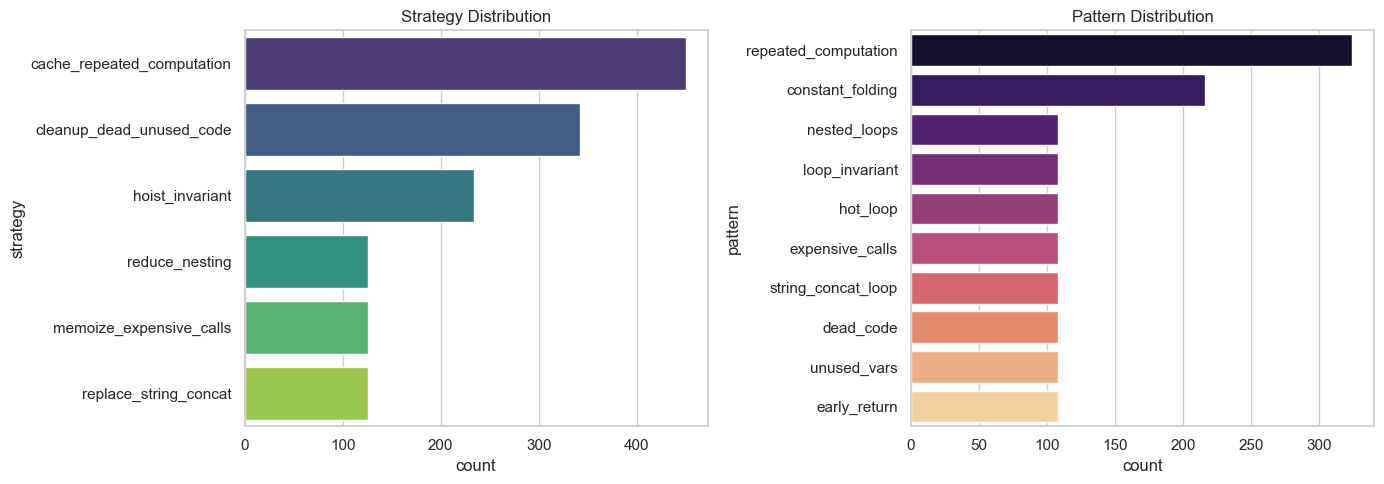

In [23]:
# plot 1: class and pattern balance
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, y="strategy",
              order=df["strategy"].value_counts().index,
              ax=axes[0], palette="viridis")

axes[0].set_title("Strategy Distribution")

sns.countplot(data=df, y="pattern",
              order=df["pattern"].value_counts().index,
              ax=axes[1], palette="magma")

axes[1].set_title("Pattern Distribution")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_01_class_balance.png"), dpi=150)
plt.show()

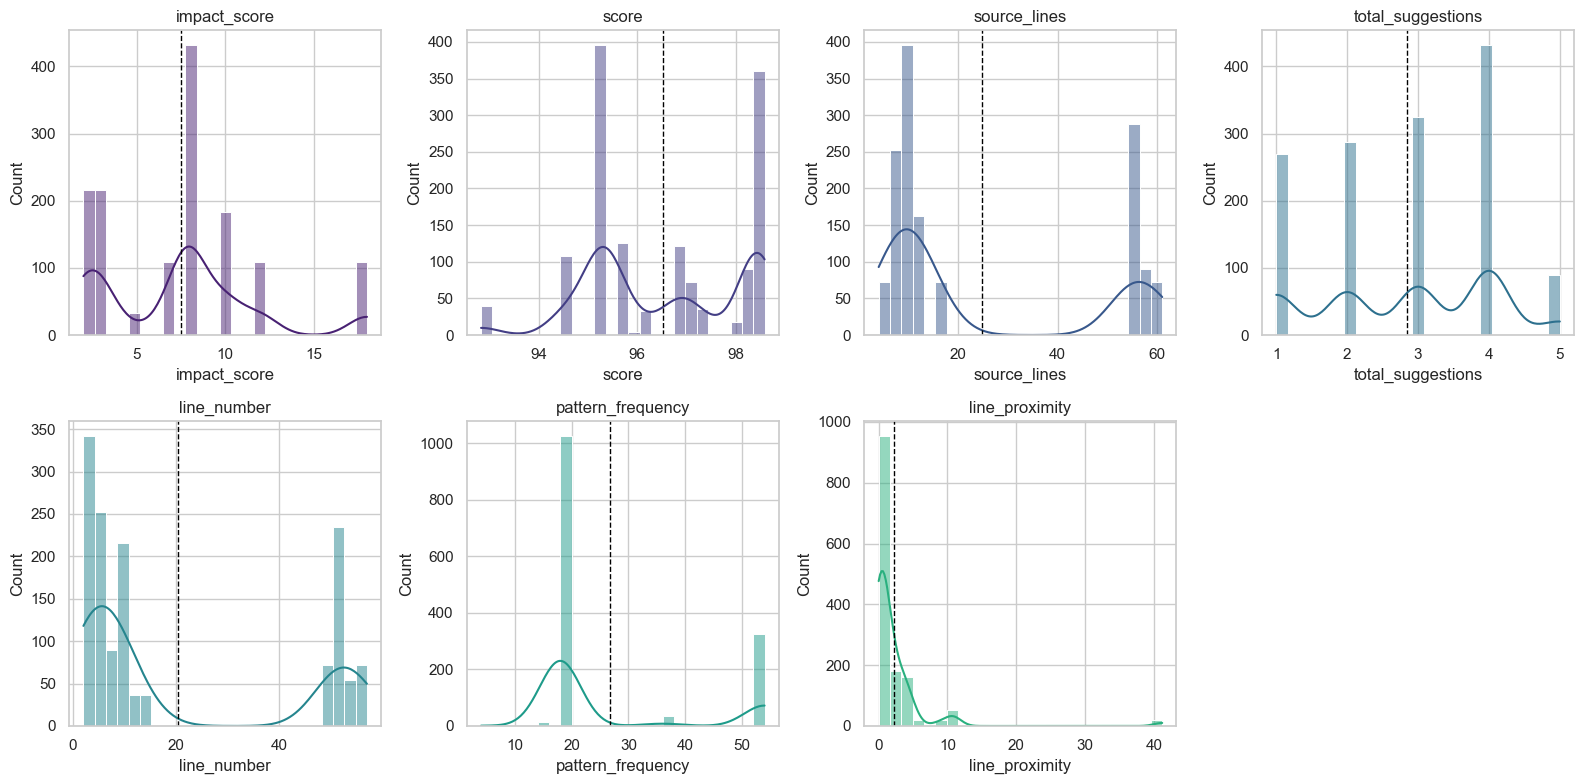

In [24]:
# plot 2: numeric feature distributions

numeric_cols = [
    "impact_score",
    "score",
    "source_lines",
    "total_suggestions",
    "line_number",
    "pattern_frequency",
    "line_proximity"
]

n = len(numeric_cols)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

palette = sns.color_palette("viridis", n_colors=10)

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df_feat[col],
        bins=25,
        kde=True,
        ax=axes[i],
        color=palette[i % len(palette)]
    )

    mean_val = df_feat[col].mean()
    axes[i].axvline(mean_val, color="black", linestyle="--", linewidth=1)
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

output_path = os.path.join(PLOTS_DIR, "eda_02_numeric_distributions.png")
plt.savefig(output_path, dpi=150)
plt.show()

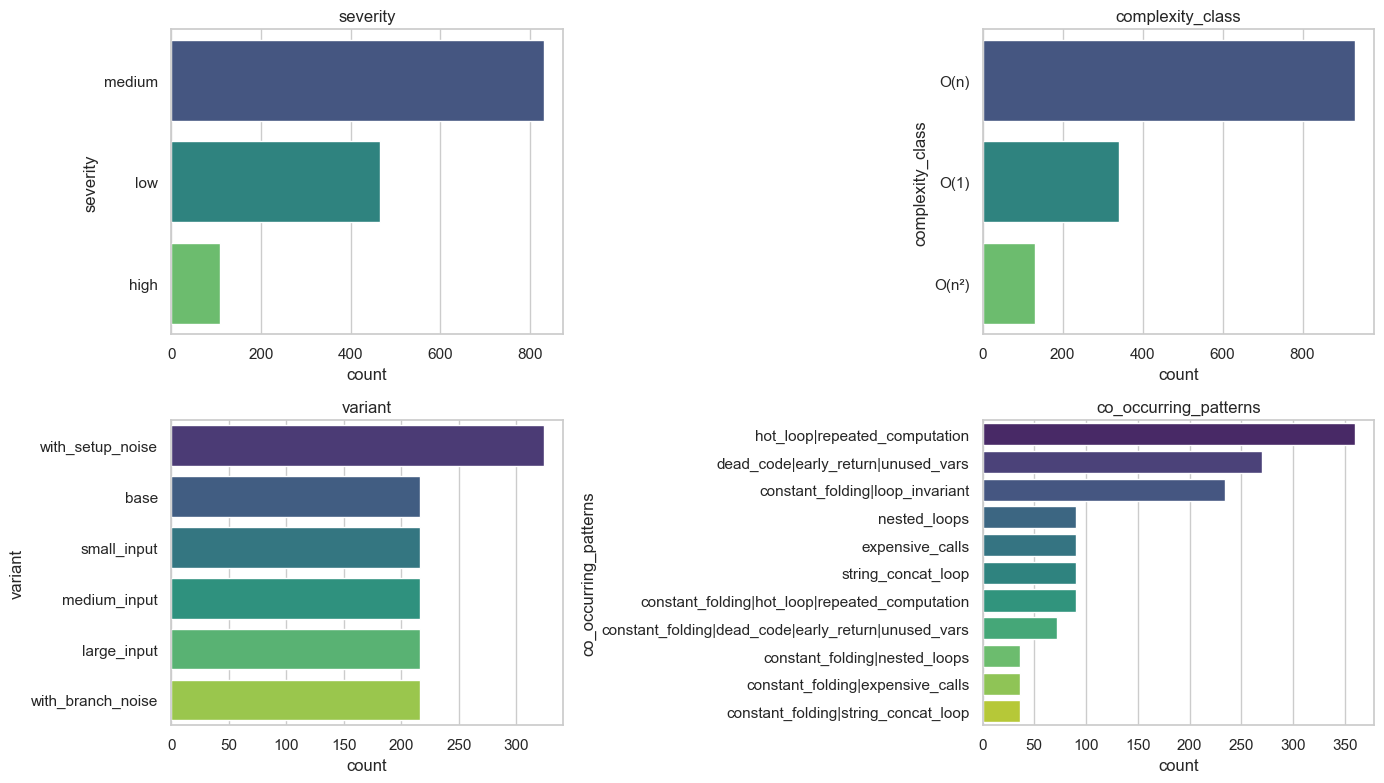

In [25]:
# plot 3: categorical feature distributions
 
cat_cols = ["severity", "complexity_class", "variant", "co_occurring_patterns"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        y=col,
        order=df[col].value_counts().index,
        ax=axes[i],
        palette="viridis"
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_03_categorical.png"), dpi=150)
plt.show()

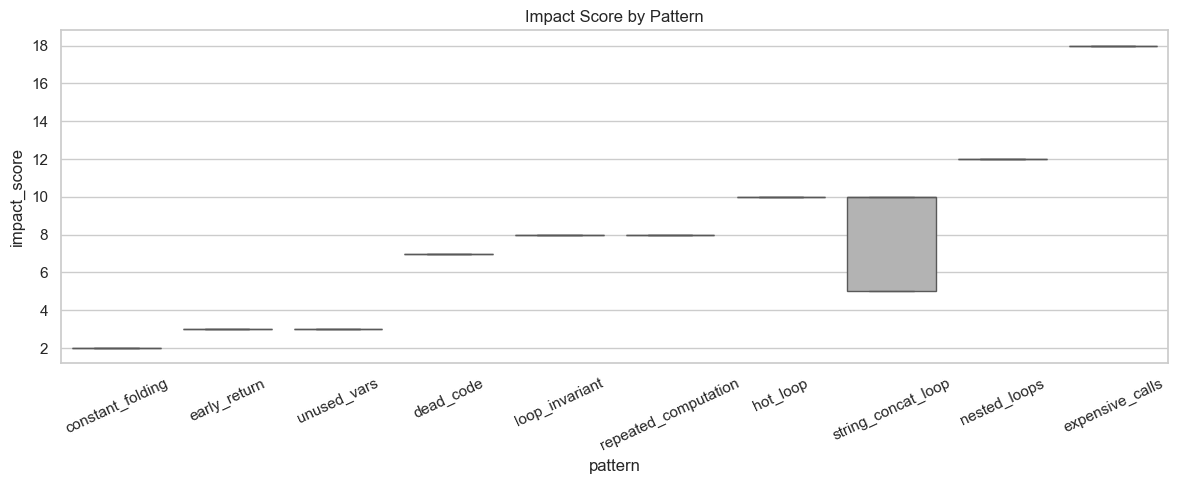

In [26]:
# plot 4: impact score by pattern (boxplot)
 
plt.figure(figsize=(12, 5))

order = df.groupby("pattern")["impact_score"].median().sort_values().index

sns.boxplot(
    data=df,
    x="pattern",
    y="impact_score",
    order=order,
    palette="Set2"
)

plt.xticks(rotation=25)
plt.title("Impact Score by Pattern")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_04_impact_by_pattern.png"), dpi=150)
plt.show()

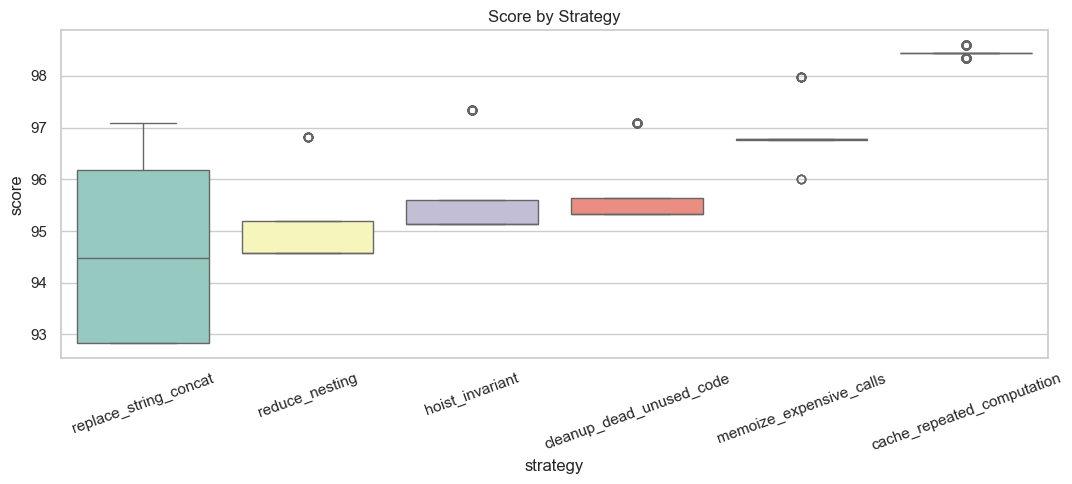

In [27]:
# plot 5: score by strategy (boxplot)
 
plt.figure(figsize=(11, 5))

order = df.groupby("strategy")["score"].median().sort_values().index

sns.boxplot(
    data=df,
    x="strategy",
    y="score",
    order=order,
    palette="Set3"
)

plt.xticks(rotation=20)
plt.title("Score by Strategy")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_05_score_by_strategy.png"), dpi=150)
plt.show()

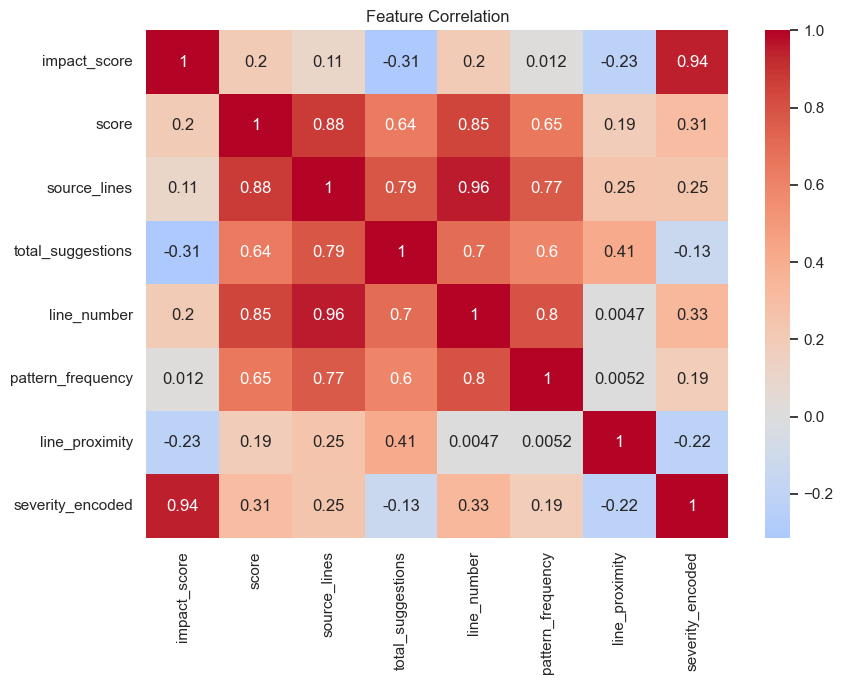

In [28]:
# plot 6: correlation heatmap (numeric features only)
 
numeric_cols = [
    "impact_score", "score", "source_lines",
    "total_suggestions", "line_number",
    "pattern_frequency", "line_proximity",
    "severity_encoded"
]

corr = df_feat[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Feature Correlation")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_06_corr.png"), dpi=150)
plt.show()

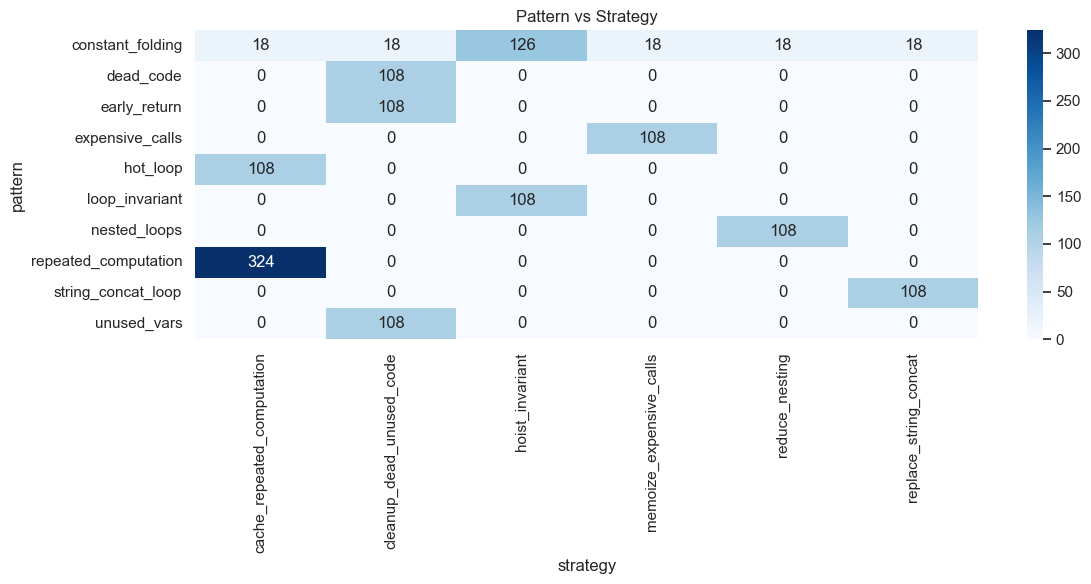

In [29]:
# plot 7: pattern × Strategy heatmap

cross = pd.crosstab(df["pattern"], df["strategy"])

plt.figure(figsize=(12, 6))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues")

plt.title("Pattern vs Strategy")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_07_cross.png"), dpi=150)
plt.show()

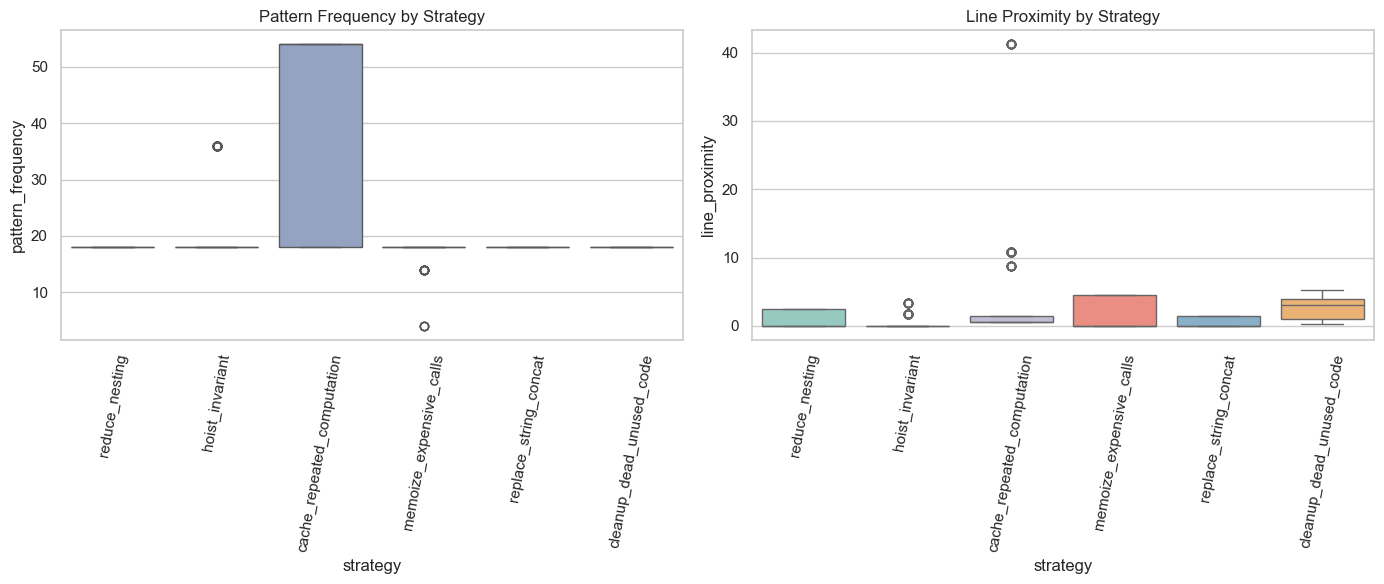

In [30]:
# plot 8: derived features by strategy

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_feat, x="strategy", y="pattern_frequency",
            ax=axes[0], palette="Set2")
axes[0].set_title("Pattern Frequency by Strategy")
axes[0].tick_params(axis='x', rotation=80)

sns.boxplot(data=df_feat, x="strategy", y="line_proximity",
            ax=axes[1], palette="Set3")
axes[1].set_title("Line Proximity by Strategy")
axes[1].tick_params(axis='x', rotation=80)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_08_derived.png"), dpi=150)
plt.show()